In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df_clean = pd.read_csv("Clean-Data")
df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])
df_clean.set_index('timestamp', inplace=True)

In [2]:
series = df_clean['total_power'].values
hist, _ = np.histogram(series, bins=30) #converted time series to probability distribution
prob = hist/np.sum(hist) #converting counts to probabilities
prob = prob[prob>0] #remove zero probabilities
entropy = -np.sum(prob*np.log2(prob))
print("Shannon Entropy:" ,entropy)

Shannon Entropy: 3.5212244335796674


In [3]:
series = df_clean['total_power'].values
N = len(series)
mean_series = np.mean(series)
Y = np.cumsum(series-mean_series) #converted data into cumulative deviation series
R = np.max(Y)-np.min(Y) #Calculated Range
S = np.std(series)
hurst = np.log(R/S)/np.log(N)
print("Hurst Exponent:",hurst)

Hurst Exponent: 0.8634294280106173


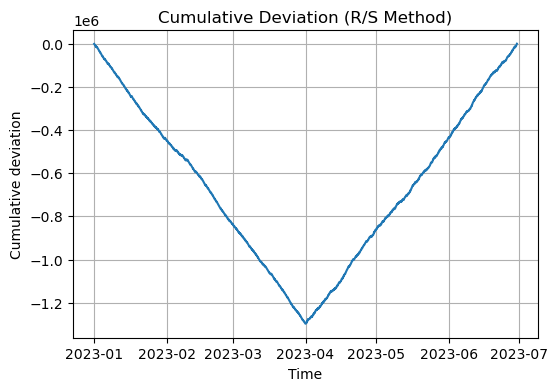

In [4]:
plt.figure(figsize=(6,4))
plt.plot(df_clean.index, Y)
plt.title("Cumulative Deviation (R/S Method)")
plt.xlabel("Time")
plt.ylabel("Cumulative deviation")
plt.grid(True)
plt.show()

In [9]:
from sklearn.preprocessing import StandardScaler
X = df_clean[['fridge','ac','lights','microwave']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
np.random.seed(42)
y_true = np.zeros(len(X_scaled))
anomaly_idx = np.random.choice(len(X_scaled), size=int(0.02*len(X_scaled)),replace=False)
X_scaled[anomaly_idx] = X_scaled[anomaly_idx]*3
y_true[anomaly_idx] = 1

In [16]:
from sklearn.svm import OneClassSVM
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_true, test_size=0.3, random_state=42)
model =  OneClassSVM(kernel='rbf',gamma=0.1,nu=0.02)
model.fit(X_train)

,kernel,'rbf'
,degree,3
,gamma,0.1
,coef0,0.0
,tol,0.001
,nu,0.02
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [17]:
y_pred = model.predict(X_test)
y_pred = np.where(y_pred==-1,1,0)

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
scores = model.decision_function(X_test)
auc = roc_auc_score(y_test,-scores)
print("Accuracy:",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1 Score:",f1)
print("AUC:",auc)

Accuracy: 0.9144178874325366
Precision: 0.4365482233502538
Recall: 1.0
F1 Score: 0.607773851590106
AUC: 1.0


In [19]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np

best_f1 = 0
best_params = {}
results = []

for nu in [0.01, 0.02, 0.03, 0.05]:
    for gamma in [0.001, 0.01, 0.1, 1]:
        
        model = OneClassSVM(kernel='rbf', nu=nu, gamma=gamma)
        model.fit(X_train)
        
        y_pred = model.predict(X_test)
        y_pred = np.where(y_pred == -1, 1, 0)
        
        f1 = f1_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        
        results.append((nu, gamma, precision, recall, f1))
        
        if f1 > best_f1:
            best_f1 = f1
            best_params = {'nu': nu, 'gamma': gamma}

print("Best Params:", best_params)
print("Best F1 Score:", best_f1)

Best Params: {'nu': 0.01, 'gamma': 0.01}
Best F1 Score: 0.9608938547486033
